In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pingouin as pg
from scipy import stats

In [2]:
df = (pd.read_csv('Pakistan_Used_Cars_Clean.csv')).drop(columns='Unnamed: 0',)
df.head(10)

,Car Name,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR),Brand,Popular degree,Price category,Trim
0,Toyota Aqua 2015 S,2015,105000,Hybrid,1500.000000,Automatic,cc,4150000.0,Toyota,3,Medium,S
1,Haval Jolion 2021 1.5T,2021,54000,Petrol,1500.000000,Automatic,cc,7000000.0,Haval,2,High,1.5T
2,Suzuki Cultus 2014 EURO II,2014,74000,Petrol,1000.000000,Manual,cc,1400000.0,Suzuki,3,Low,EURO II
3,Suzuki Wagon R 2017 VXL,2017,89000,Petrol,1000.000000,Manual,cc,2375000.0,Suzuki,3,Medium,VXL
4,DFSK Glory 580 2022 Pro,2022,40000,Petrol,1500.000000,Automatic,cc,5300000.0,DFSK,1,High,Pro
5,Jaecoo J7 2026 Premium,2026,12000,PHEV,1500.000000,Automatic,cc,10600000.0,Jaecoo,1,High,Premium
6,Suzuki Baleno 2005 JXR,2005,180000,Petrol,1300.000000,Manual,cc,1190000.0,Suzuki,3,Low,JXR
7,Toyota Hilux 2016 Vigo Champ GX,2016,59000,Diesel,1420.121901,Automatic,cc,7500000.0,Toyota,3,High,Vigo Champ GX
8,Haval H6 2024 HEV,2024,36000,Hybrid,1500.000000,Automatic,cc,9900000.0,Haval,2,High,HEV
9,Jaecoo J7 2026 Premium,2026,12300,PHEV,1500.000000,Automatic,cc,10100000.0,Jaecoo,1,High,Premium


In [3]:
df_actual = df[(df['Model Year'] >= 2000) & (df['Popular degree'].isin([2,3]))]
df_actual.shape

(50442, 12)

In [4]:
df_actual.columns = ['Car Name', 'Model Year', 'Mileage', 'Fuel Type', 'Engine Capacity',
       'Transmission', 'Engine Unit', 'Price', 'Brand', 'Popular degree',
       'Price category', 'Trim']

In [5]:
fuel = ['Petrol', 'Hybrid', 'Diesel', 'CNG']

In [6]:
df_actual = df_actual[(df_actual['Engine Unit'] == 'cc') & (df_actual['Fuel Type'].isin(fuel))]

In [7]:
df_actual = df_actual.drop(columns=['Car Name', 'Price category', 'Popular degree', 'Engine Unit'])


In [8]:
df_actual

,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Price,Brand,Trim
0,2015,105000,Hybrid,1500.0,Automatic,4150000.0,Toyota,S
1,2021,54000,Petrol,1500.0,Automatic,7000000.0,Haval,1.5T
2,2014,74000,Petrol,1000.0,Manual,1400000.0,Suzuki,EURO II
3,2017,89000,Petrol,1000.0,Manual,2375000.0,Suzuki,VXL
6,2005,180000,Petrol,1300.0,Manual,1190000.0,Suzuki,JXR
...,...,...,...,...,...,...,...,...
57631,2018,128000,Petrol,1000.0,Manual,2615000.0,Suzuki,VXL
57632,2014,26000,Petrol,796.0,Manual,1150000.0,Suzuki,VXR Euro II
57633,2023,70000,Petrol,1000.0,Automatic,4500000.0,Toyota,X
57634,2018,76700,Petrol,1300.0,Automatic,5475000.0,Toyota,Altis Grande CVT-i 1.8


<Axes: >

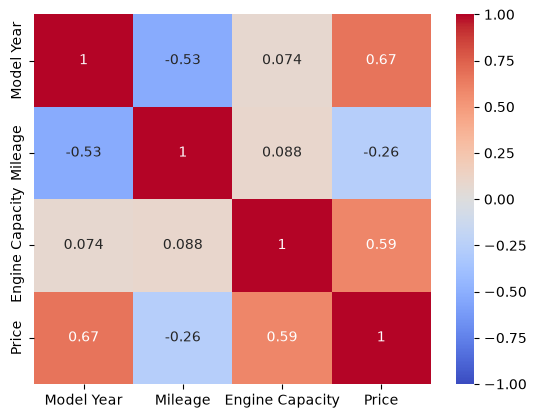

In [9]:
corr_mat = df_actual.select_dtypes([int, float]).corr(method='spearman')
sns.heatmap(corr_mat, vmin=-1, vmax=1, cmap='coolwarm', annot=True)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26],
 [Text(0, 0, '2000'),
  Text(1, 0, '2001'),
  Text(2, 0, '2002'),
  Text(3, 0, '2003'),
  Text(4, 0, '2004'),
  Text(5, 0, '2005'),
  Text(6, 0, '2006'),
  Text(7, 0, '2007'),
  Text(8, 0, '2008'),
  Text(9, 0, '2009'),
  Text(10, 0, '2010'),
  Text(11, 0, '2011'),
  Text(12, 0, '2012'),
  Text(13, 0, '2013'),
  Text(14, 0, '2014'),
  Text(15, 0, '2015'),
  Text(16, 0, '2016'),
  Text(17, 0, '2017'),
  Text(18, 0, '2018'),
  Text(19, 0, '2019'),
  Text(20, 0, '2020'),
  Text(21, 0, '2021'),
  Text(22, 0, '2022'),
  Text(23, 0, '2023'),
  Text(24, 0, '2024'),
  Text(25, 0, '2025'),
  Text(26, 0, '2026')])

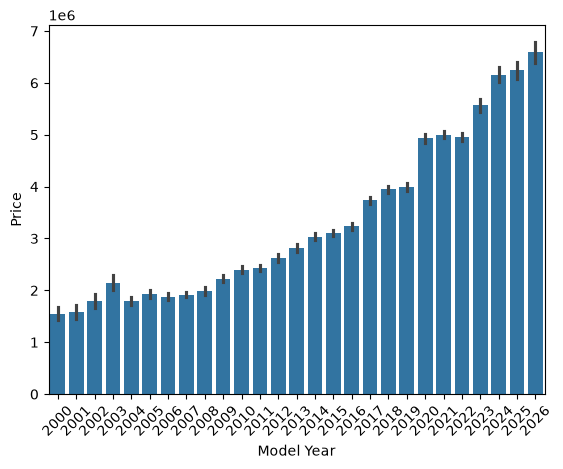

In [10]:
sns.barplot(df_actual, x='Model Year', y='Price')
plt.xticks(rotation=45)

<Axes: xlabel='Engine Capacity', ylabel='Price'>

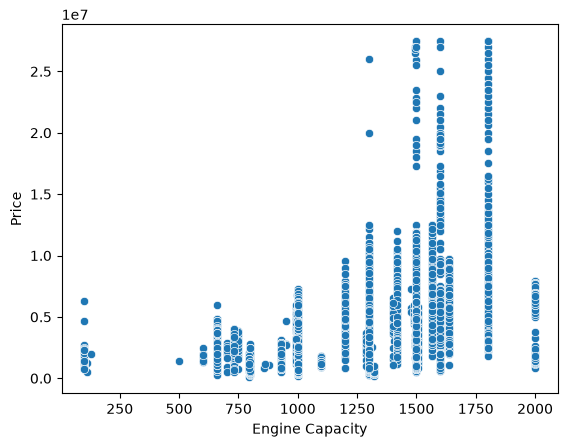

In [11]:
sns.scatterplot(df_actual, x='Engine Capacity', y='Price')

<Axes: xlabel='Mileage', ylabel='Price'>

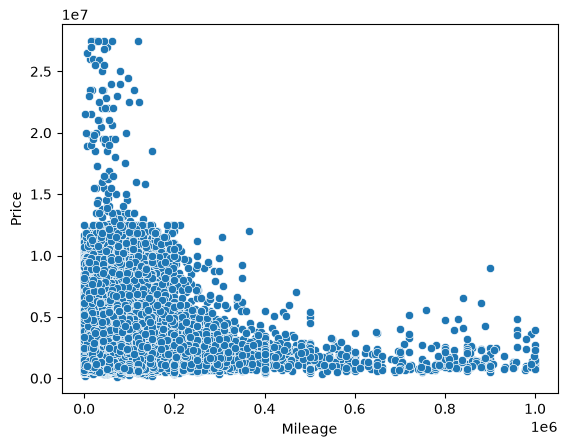

In [12]:
sns.scatterplot(df_actual, x='Mileage', y='Price')

In [13]:
df_actual[(df_actual['Price'] < 500000) & (df_actual['Mileage'] < 100000)]

,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Price,Brand,Trim
75,2009,83000,Petrol,1300.0,Manual,280000.0,Honda,1.3 i-VTEC
201,2004,50000,CNG,800.0,Manual,490000.0,Suzuki,VXR
1619,2005,68000,Petrol,800.0,Manual,380000.0,Suzuki,VX
1788,2001,52522,Petrol,800.0,Manual,480000.0,Suzuki,VXR (CNG)
7560,2009,10000,Petrol,800.0,Manual,470000.0,Suzuki,VXR
9845,2015,71900,Petrol,796.0,Manual,130000.0,Suzuki,VXR Euro II
10659,2002,1239,CNG,1323.0,Manual,195000.0,KIA,LX
11811,2005,56000,Petrol,800.0,Manual,480000.0,Suzuki,VXR
12964,2002,68000,Petrol,800.0,Manual,440000.0,Suzuki,VX
16275,2002,999,Petrol,800.0,Manual,450000.0,Suzuki,VXR


<Axes: xlabel='Fuel Type', ylabel='Price'>

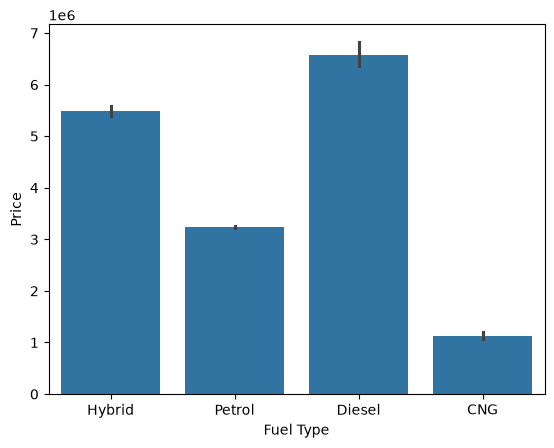

In [14]:
sns.barplot(df_actual, x='Fuel Type', y='Price')

<Axes: xlabel='Transmission', ylabel='Price'>

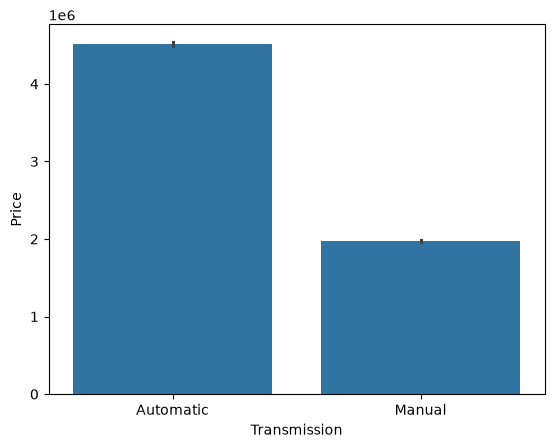

In [15]:
sns.barplot(df_actual, x='Transmission', y='Price')

In [16]:
df_actual['LogPrice'] = np.log1p(df_actual['Price'])

In [17]:
pg.anova(data=df_actual, dv='LogPrice', between=['Fuel Type', 'Transmission'])

,Source,SS,DF,MS,F,p_unc,np2
0,Fuel Type,649.371608,3.0,216.457203,861.061035,0.000000e+00,0.048998
1,Transmission,7578.230751,1.0,7578.230751,30146.001764,0.000000e+00,0.375497
2,Fuel Type * Transmission,10.812270,3.0,3.604090,14.336975,2.469540e-09,0.000857
3,Residual,12603.653318,50137.0,0.251384,NaN,NaN,NaN


In [18]:
pg.anova(data=df_actual, dv='LogPrice', between=['Brand'])

,Source,ddof1,ddof2,F,p_unc,np2
0,Brand,11,50133,4402.3023,0.0,0.491337


In [19]:
pg.anova(data=df_actual, dv='LogPrice', between=['Trim'])

,Source,ddof1,ddof2,F,p_unc,np2
0,Trim,961,49183,230.078926,0.0,0.818035
